# Task 2: Gestalt principles of grouping

**CLO1:** how the brain processes visual information.

The six panels in `stimuli_gestalt.csv` use almost the same dots. Only the arrangement changes, so any grouping I see comes from the layout and not from the numbers.

Same set-up as Task 1: the drawing and the tips charts run now. The "how many groups do you see?" questions need a real person, so they live in a function I run by hand and that writes `gestalt_answers.csv`.

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import clear_output

g = pd.read_csv("stimuli_gestalt.csv")
MARK = {"circle": "o", "square": "s", "triangle": "^"}
PRINCIPLE = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]
print(g.groupby("panel").agg(items=("x", "size"), groups=("group", "nunique")).loc[PRINCIPLE])

            items  groups
panel                    
proximity      48       4
similarity     48       4
enclosure      48       4
continuity     48       2
closure        44       2
connection     48      24


## Step 1: draw all six panels
`enclosure` gets four grey rectangles, one around each clump (bounding box plus padding). `connection` gets a line between the two items that share a `connector` value. I left the 44 dots in `closure` alone: the gap is the stimulus.

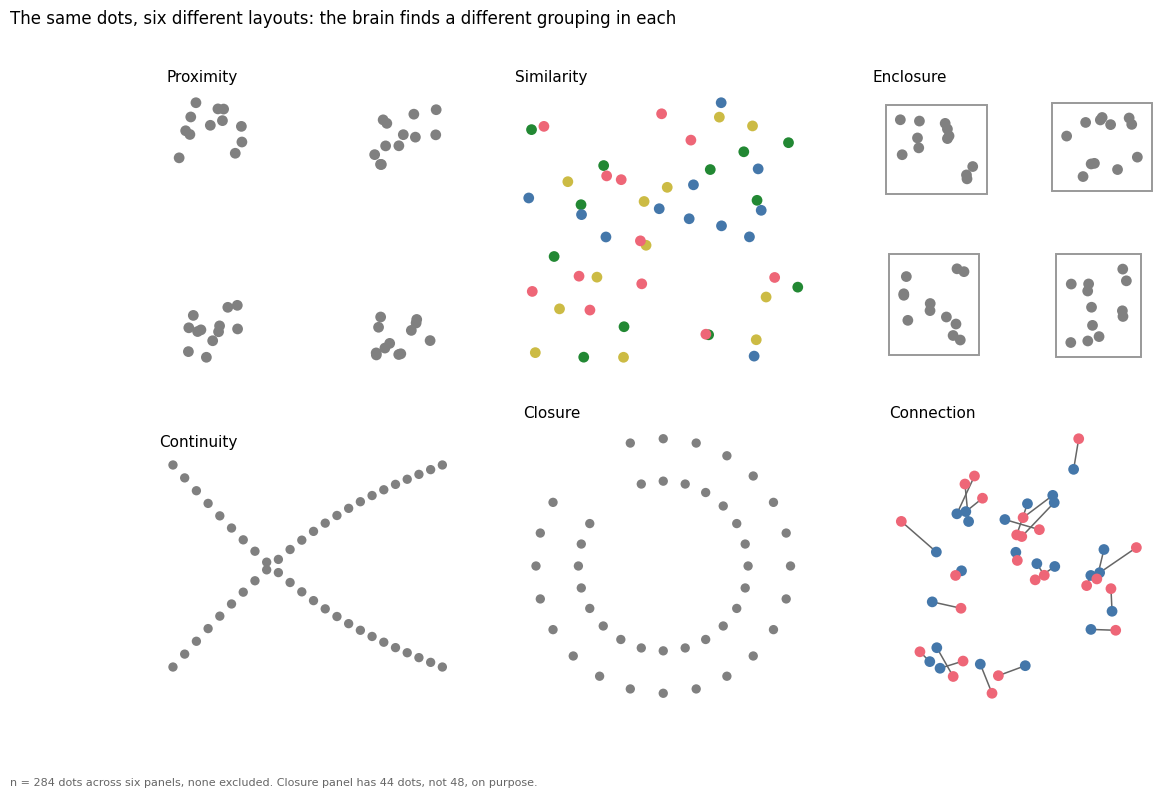

In [2]:
def draw_panel(ax, panel, boxes=True, lines=True):
    d = g[g.panel == panel]
    for (colour, shape), part in d.groupby(["colour", "shape"]):
        ax.scatter(part.x, part.y, s=part["size"], color=colour,
                   marker=MARK.get(shape, "o"), edgecolor="none", zorder=3)
    if panel == "enclosure" and boxes:
        for _, grp in d.groupby("group"):
            pad = 0.45
            x0, y0 = grp.x.min() - pad, grp.y.min() - pad
            ax.add_patch(Rectangle((x0, y0), grp.x.max() - grp.x.min() + 2 * pad,
                                   grp.y.max() - grp.y.min() + 2 * pad,
                                   fill=False, edgecolor="#999999", lw=1.4, zorder=1))
    if panel == "connection" and lines:
        for _, pair in d.groupby("connector"):
            ax.plot(pair.x, pair.y, color="#666666", lw=1.1, zorder=2)
    ax.set_aspect("equal")
    ax.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, p in zip(axes.ravel(), PRINCIPLE):
    draw_panel(ax, p)
    ax.set_title(p.capitalize(), loc="left", fontsize=11)
fig.suptitle("The same dots, six different layouts: the brain finds a different grouping in each",
             x=0.01, ha="left", fontsize=12)
fig.text(0.01, 0.01, "n = 284 dots across six panels, none excluded. Closure panel has 44 dots, not 48, on purpose.",
         fontsize=8, color="#666666")
fig.savefig("t2_six_panels.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 2 and 3: ask a real person

The runner shows each panel **without** its title (the title would give away the answer), in random order, and asks how many groups they see and what they grouped by. The `connection` panel is shown twice: once without lines, once with. That is step 3, the principles-fight-each-other test.

To run it: set `RUN_EXPERIMENT = True`, type the person's first name, hand them the keyboard.

In [3]:
RUN_EXPERIMENT = False
READER = "a classmate"

def run_gestalt_questions(reader):
    items = [(p, "plain") for p in ["proximity", "similarity", "enclosure", "continuity", "closure"]]
    items += [("connection", "no_lines"), ("connection", "lines")]
    random.Random(7).shuffle(items)
    # make sure the no-lines version comes before the lines version, so the lines can't prime them
    i_no = items.index(("connection", "no_lines")); i_yes = items.index(("connection", "lines"))
    if i_yes < i_no:
        items[i_no], items[i_yes] = items[i_yes], items[i_no]
    rows = []
    for panel, version in items:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(5, 5))
        draw_panel(ax, panel, lines=(version == "lines"))
        plt.show()
        n = ""
        while not n.strip().isdigit():
            n = input("How many groups do you see? (a number): ")
        how = input("What made you group them that way? (a few words): ")
        rows.append(dict(reader=reader, panel=panel, version=version,
                         perceived_groups=int(n), how_grouped=how))
    clear_output()
    out = pd.DataFrame(rows)
    out.to_csv("gestalt_answers.csv", index=False)
    print("saved gestalt_answers.csv")
    return out

if RUN_EXPERIMENT:
    run_gestalt_questions(READER)

**Who was my reader:** _(first name, anything relevant)_

**What I asked:** "How many groups do you see?" and then "what made you group them that way?", one panel at a time, titles hidden, order shuffled.

In [4]:
TRUE_GROUPS = g.groupby("panel").group.nunique()
if os.path.exists("gestalt_answers.csv"):
    ans = pd.read_csv("gestalt_answers.csv")
    ans["principle"] = ans.panel
    ans["true_groups"] = ans.panel.map(TRUE_GROUPS)
    ans["match"] = np.where(ans.perceived_groups == ans.true_groups, "yes", "no")
    shown = ans[ans.version != "no_lines"]
    print(shown[["panel", "principle", "true_groups", "perceived_groups", "match"]].to_string(index=False))
    print("\nConnection panel, both versions:")
    print(ans[ans.panel == "connection"][["version", "perceived_groups", "how_grouped"]].to_string(index=False))
else:
    print("gestalt_answers.csv doesn't exist yet. Run the questions (RUN_EXPERIMENT = True) and re-run.")

gestalt_answers.csv doesn't exist yet. Run the questions (RUN_EXPERIMENT = True) and re-run.


**Which principle won in the connection panel? (write this after you see the answers).** Compare the "no lines" answer with the "lines" answer. If the reader went from something like 2 groups (colour, similarity) or a few clumps (proximity) to 24 once the lines went on, connection beat both. If they didn't, say so and why: maybe the lines were thin, maybe they counted pairs in the first version too, maybe the colours were too strong a cue.

_Your result here: ___

## Step 4: proximity in a real chart (`tips.csv`)
Average tip rate (tip / total bill) by day, split by sex. Version A groups the two bars of each day with a small gap inside the day and a big gap between days. Version B spaces all eight bars evenly. The data are identical.

Gestalt principle used in A: **proximity**. Women are the one pop-out (strong colour), men are grey context, and both are labelled directly so colour isn't carrying the meaning alone.

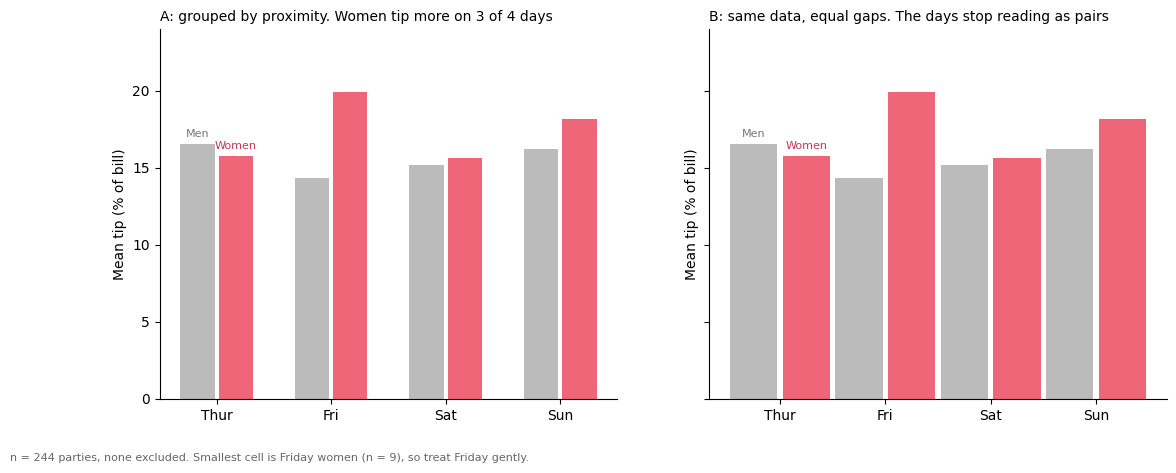

sex   Female   Male
day                
Thur   15.75  16.53
Fri    19.94  14.34
Sat    15.65  15.16
Sun    18.16  16.23


In [5]:
tips = pd.read_csv("tips.csv")
tips["pct"] = tips.tip / tips.total_bill * 100
days = ["Thur", "Fri", "Sat", "Sun"]
m = tips.groupby(["day", "sex"]).pct.mean().unstack().loc[days]
n_party = tips.groupby(["day", "sex"]).size().unstack().loc[days]
women_higher = int((m.Female > m.Male).sum())

def grouped_bars(ax, positions, title, centres):
    for i, d in enumerate(days):
        ax.bar(positions[2 * i], m.loc[d, "Male"], width=0.9, color="#bbbbbb")
        ax.bar(positions[2 * i + 1], m.loc[d, "Female"], width=0.9, color="#ee6677")
    ax.set_xticks(centres)
    ax.set_xticklabels(days)
    ax.set_ylim(0, 24)
    ax.set_ylabel("Mean tip (% of bill)")
    ax.set_title(title, loc="left", fontsize=10)
    ax.text(positions[0], m.loc["Thur", "Male"] + 0.5, "Men", ha="center", fontsize=8, color="#777777")
    ax.text(positions[1], m.loc["Thur", "Female"] + 0.5, "Women", ha="center", fontsize=8, color="#cc3355")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

posA = [i * 3 + o for i in range(4) for o in (0, 1)]       # inside gap 0.1, between gap 1.1
posB = [float(k) for k in range(8)]                        # every gap 0.1
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
grouped_bars(axA, posA, f"A: grouped by proximity. Women tip more on {women_higher} of 4 days", [i * 3 + 0.5 for i in range(4)])
grouped_bars(axB, posB, "B: same data, equal gaps. The days stop reading as pairs", [i * 2 + 0.5 for i in range(4)])
fig.text(0.01, -0.02, f"n = {len(tips)} parties, none excluded. Smallest cell is Friday women (n = {n_party.loc['Fri', 'Female']}), so treat Friday gently.",
         fontsize=8, color="#666666")
fig.savefig("t2_tips_proximity.png", dpi=300, bbox_inches="tight")
plt.show()
print(m.round(2))

**What the reader loses in B.** Nothing in the numbers changed, but the reader loses the quick answer to "compare men and women *within* a day". In A, the small gap tells the eye that two bars are a pair, so it compares them without being told. In B every bar is equally far from its neighbours, so a bar sits as close to the next day's bar as to its own partner. The eye falls back on colour (similarity) and starts comparing all the grey bars to each other, which is a different question than the one I wanted answered. The reader now has to do the grouping by reading the tick labels, and that is work I moved from the layout onto working memory.

## Step 5: where each principle already lives in a chart I know
- **Proximity:** the bars of one category in a grouped bar chart sitting closer to each other than to the next category (what I just did above).
- **Similarity:** every dot of one colour in a scatter plot being read as one series, which is exactly what a legend relies on.
- **Enclosure:** a shaded band behind a stretch of a line chart (say, a recession), or a box drawn round a cluster of points, so everything inside reads as one thing.
- **Closure:** a dashed or dotted trend line, or a line chart with a gap in the data, that the brain completes into one continuous line; also the open-ended bracket on a bar chart that we still read as a box.
- **Continuity:** the line in a line chart. Dots joined on a smooth path read as one trend, and when two lines cross we still follow each one straight through the crossing.
- **Connection:** the lines in a slope chart or dumbbell plot joining a "before" dot to an "after" dot. The link beats colour and distance.

## The question: what does direct labelling use instead of a legend, and why is it cheaper?
Direct labelling uses **proximity** (the name sits right next to the thing it names), sometimes with **connection** if there's a small leader line.

In terms of load: a legend makes me do four things. I look at the line or dot, memorise its colour, travel to the legend, find the matching swatch, read the name, and carry that name back to the chart. That colour-to-name pair has to be held in working memory the whole time, and with five series I'm juggling about five pairs, which is already near the 4 +/- 1 limit. All of that is **extraneous load**, because it's work caused by how I drew the chart and not by the data. A direct label removes the lookup completely: the proximity principle makes the name part of the object, so there's no mapping to hold and no trip across the page. The effort that remains is the useful kind, comparing the series (germane load).